# Day 13!

### Sidenote on Likelihood

> First of all, for some reason it took me this long to understand but the Likelihood within Bayesian inference follows the data distribution. It uses the exact same equations as the data, just asks a different question. 
>
> For example
> If we use the normal distribution:
>$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right)$$
> If we vary our data, $x$, and keep the parameters, $\mu$ the same, we are looking at the probability distrubution or the data generating distribution, this created the data that we see.
> If we keep $x$ the same, but vary $\mu$ then we have the likelihood. The likelihood is NOT a probability distribution

### Sidenote on Evidence

> The Evidence is called the MARGINAL LIKELIHOOD, this means that all you have to do to get the evidence is integrate it across all possible parameter values, weighted by the prior. We would essentially be looking at on average, how well does the entire model explain the data
>
> We can also think of it as the probability of seeing the data before we actually looked at it, based purely on the model (this includes the likelihood and prior).



## Lecture 10 - MCMC

Usually exhaustive search of the posterior pdf is impossible when we have a large amount of parameters. So we need some numerical methods that are more efficient.

The 2 problems we may encounter:
1. We wish to marginalise and estimate parameters
2. Model comparison

#### MCMC

MCMC allows us to sample the full multidimensional parameter space in a way that builds samples whos density is proportional to the posterior density.

##### What is Monte Carlo?

We saw this before in a previous day, where we used monte carlo integration.

If we don't know the value of pi, we can use the area of a square and draw a circle around it. These are the steps:

1. Draw a square and inscribe a circle (this just means the circle touches the sides of the square) inside it.
2. Throw random points into the square and note the ones that land in the circle
3. We calculate a ratio of the random points in the circle to the total random points (in the quater circle example we will multiply by 4 after)
4. If we use more points, we get a more precise estimate of the area

Let's see this in code for a quater circle.


In [17]:
# Execute this cell
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

Estimate of pi is 3.1292 for 10000 draws with fractional error 0.0039447041536821974.


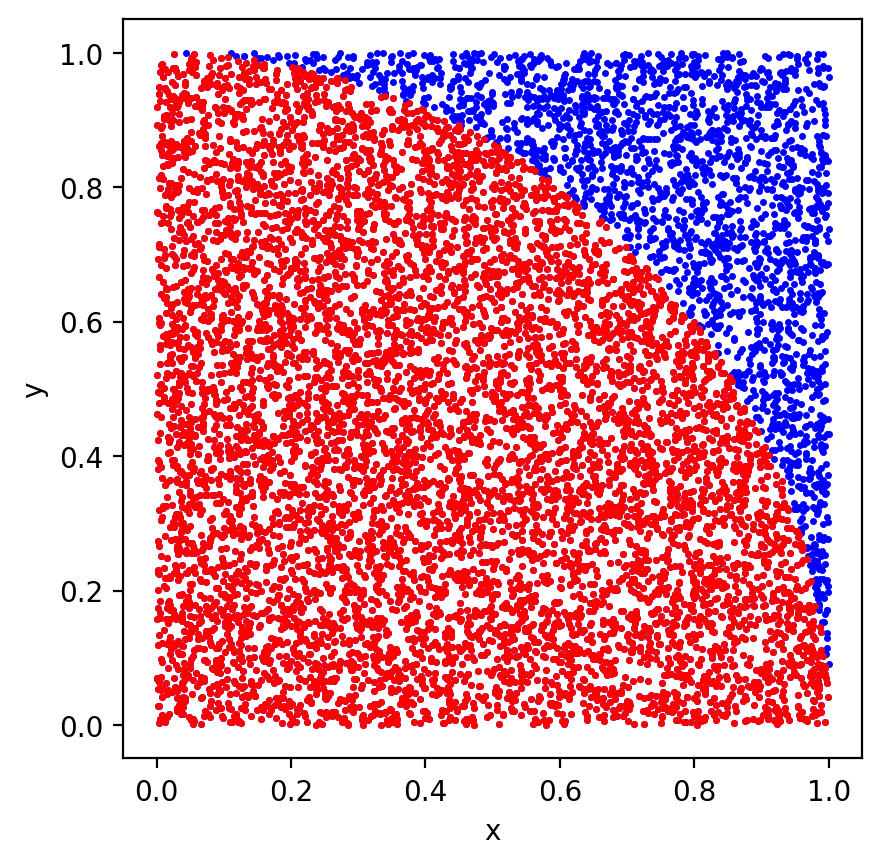

In [18]:
# Lay down M random points.  Tally how many are within a unit circle.
M = 10000
x = stats.uniform(0,1).rvs(M) # M random draws between 0 and 1
y = stats.uniform(0,1).rvs(M) # M random draws between 0 and 1

r2 = x**2+y**2 # equation for radius^2 of cirle in x,y

fig, ax = plt.subplots(subplot_kw=dict(aspect='equal'))

# Plot points in square
plt.plot(x, y, '.', 
         markersize=3, c='blue') 

# Plot points also in circle
plt.plot(x[r2 < 1], y[r2 < 1], '.', 
         markersize=3, c='red') 

#ax.axis([0, 1, 0, 1], aspect='equal');
plt.xlabel('x')
plt.ylabel('y')
    
# A_square = d^2, Acircle = pi*d^2
piEst = 4 * np.sum(r2 < 1) / M # pi = 4A/d^2, where A is d^2 times the ratio of points "in" to total points

print("Estimate of pi is {0} for {1} draws with fractional error {2}.".format(piEst, M, 
                                                                              np.abs((np.pi-piEst)/np.pi)))

So we can use random sampling to get a generic result. 

In general we need to evaluate the multidimensional integral:

$$I = \int g(\theta) p(\theta) \, d\theta$$

Where $p(\theta)$ is the posterior probability.

This is very similar to what we had to do for monte carlo integration. 

### What is a Markov Chain?

> This is a sequence of random variables where a parameter depends only on the preceding value, this is memoryless

This can be written mathematically:

$$p(\theta_{i+1}|\theta_i, \theta_{i-1}, \theta_{i-2}, \cdots) = p(\theta_{i+1}|\theta_i).$$

Remember, it only depends on the last value.

For equilibrium (reaching a stationary distribution or convergence), it is necessary for the transition probability to be symmetric such that:

$$p(\theta_{i+1}|\,\theta_i) = p(\theta_i |\, \theta_{i+1}).$$

This is known as the principle of detailed balance. All it really means is that symmetrically, the proposal does not favour one direction over the reverse.

This is only for the simple metropolis algorithm considered.

### MCMC techniques

> Now we use Markov chains to perform monte carlo integration

Given a chain length of N, corresponding to draws of $p(\theta)$, the integrals can be estimated as:

$$\int g(\theta) \, p(\theta) \, d\theta \approx {1 \over N} \sum_{i=1}^Ng(\theta_i).$$

1. So to estimate the expectation value for $\theta_1$ we take mean value of all $\theta_1$ within the chain
2. To visualise the posterior pdf for $\theta_1$, marginalised over all other parameters, we can construct a histogram of all $\theta_1$ values in the chain and normalise its integral to 1
3. To get a MAP estimate for $\theta_1$ we find the maximum of the marginalised pdf

For the Markov chain to accurately sample from the posterior, $p(\theta)$, it must reach a stationary distribution. The probability of arriving at a new position $\theta_{i+1}$ depends on the proposal distribution $T(\theta_{i+1} | \theta_{i})$

$$p(\theta_{i+1}) = \int  T(\theta_{i+1}|\theta_i)  \,   p(\theta_i) \,    d \theta_i,$$

This distribution propses new positions to jump to in the parameter space. Where $T(\theta_{i+1} | \theta_i)$ is called the jump kernal. 

This requirement is satisfied when the transition probability satisfies the principle of detailed balance.

$$T(\theta_{i+1}|\theta_i)  \,  p(\theta_i) = T(\theta_i|\theta_{i+1})  \,  p(\theta_{i+1}).$$

And this means that at equilibrium, the total probability flow from one state to another is balanced by the reverse flow. 
> This can be thought of as flux as well, so flux from two states equals the reverse flux in equilibrium


Supposedly the trickiest parts of MCMC come from deciding how to step from one position to the next. Ideally, we want random sampling that preferentially steps into regions of high probability density

The most common used algorithm for stepping from one place to another is the:

### Metropolis-Hastings algorithm

The Metropolis Hastings algorithm uses the kernel:

$$T(\mathbf{\theta}_{i+1} | \mathbf{\theta}_i) = p_{\text{acc}}(\mathbf{\theta}_i, \mathbf{\theta}_{i+1}) K(\mathbf{\theta}_{i+1} | \mathbf{\theta}_i)$$

Where the proposed density distribution $K(\theta_{i+1}|\theta_i)$ is an arbitrary function, such as the normal distribution that proposes to the algorithm where it should look next

It uses the acceptance probability:

$$p_{\text{acc}}(\mathbf{\theta}_i, \mathbf{\theta}_{i+1}) = \frac{K(\mathbf{\theta}_i | \mathbf{\theta}_{i+1}) p(\mathbf{\theta}_{i+1})}{K(\mathbf{\theta}_{i+1} | \mathbf{\theta}_i) p(\mathbf{\theta}_i)}$$

Usually, a symmetric proposal distribution is used, such as the normal distribution centered on $\theta_i$. This causes $K(\theta_{i+1}|\theta_i) = K(\theta_{i}|\theta_{i+1}) $, cancelling it out from the acceptance ratio

If the acceptance ratio exceeds 1, then the proposal point is always accepted. If not, then it is accepted with a probability of $p(\theta_{i+1} / p(\theta_i))$. When $\theta_{i+1}$ is rejected, then we instead add $\theta_i$ to the chain.

**The idea of this algorithm is that it follows**:

1. Given $\theta_i$ and $T(\theta_{i+1}|\theta_i)$ draw a proposed value for $\theta_{i+1}$
2. Compute the acceptable probability $p_{acc}(\theta_i, \theta_{i+1})$

> $$\alpha = \min \left( 1, \frac{p(\theta^* \mid D) \, q(\theta_i \mid \theta^*)}{p(\theta_i \mid D) \, q(\theta^* \mid \theta_i)} \right)$$
> In our case our proposal distribution is symmetric so it can foillow:
> $$\alpha = \min \left( 1, \frac{p(\theta^* \mid D)}{p(\theta_i \mid D)} \right)$$

3. Draw a random value between 0 and 1 from a uniform distribution, if it is smaller than $p_{\rm acc}(\theta_i,\theta_{i+1})$, then accept $\theta_{i+1}$
4. If we accept $\theta_{i+1}$ add it to the chain, if not $\theta_i$ is added
5. The resulting $\theta_i$ should be distributed according to the posterior

Proposals with higher probability than the current point is always accepted. If there is a proposal with lower (posterior) probability, then it can still be accepted. Accepting some lower probability proposals, helps to map out the entire posterior instead of climbing to the maximum.


### Worked Example


[ 2.88479061e-01 -4.62954082e-01 -1.33800442e+00  2.31701567e+00
 -1.46737593e+00 -7.48547692e-01 -1.01752136e+00  1.63506680e+00
  9.22545612e-01 -7.19881325e-01 -9.64883392e-01  2.53582786e-01
  3.08007397e-01 -7.16059964e-02 -1.13548051e+00 -1.02245395e-01
  8.08186231e-01  2.31992388e-01 -1.40035848e+00  7.15907784e-01
 -2.12456763e+00  1.24141343e+00  2.36311955e-01 -1.08889182e+00
  7.17759193e-01  4.34044855e-02 -2.95264204e-01 -1.97157944e-01
  8.07860271e-01 -1.07675649e+00  4.91332541e-01 -4.51135913e-01
  1.96590360e-01 -2.15841568e+00  5.22697289e-01  1.94262177e-01
  5.37928619e-02 -9.43646239e-02  7.50434316e-01 -2.30255338e+00
  6.83408743e-01  1.11628075e+00  8.53109930e-01  1.22496261e+00
  2.81857584e-01 -2.47099714e-01  2.04519912e+00 -6.63445218e-01
 -3.13508908e-01 -1.13584237e+00  6.47905394e-01  8.44965908e-01
  1.58433578e+00 -1.65264548e-02 -7.95746936e-01  3.86873352e-01
 -1.21269907e+00  7.55909490e-01  6.52870393e-01 -4.91741982e-01
  3.06197309e-01 -5.33482

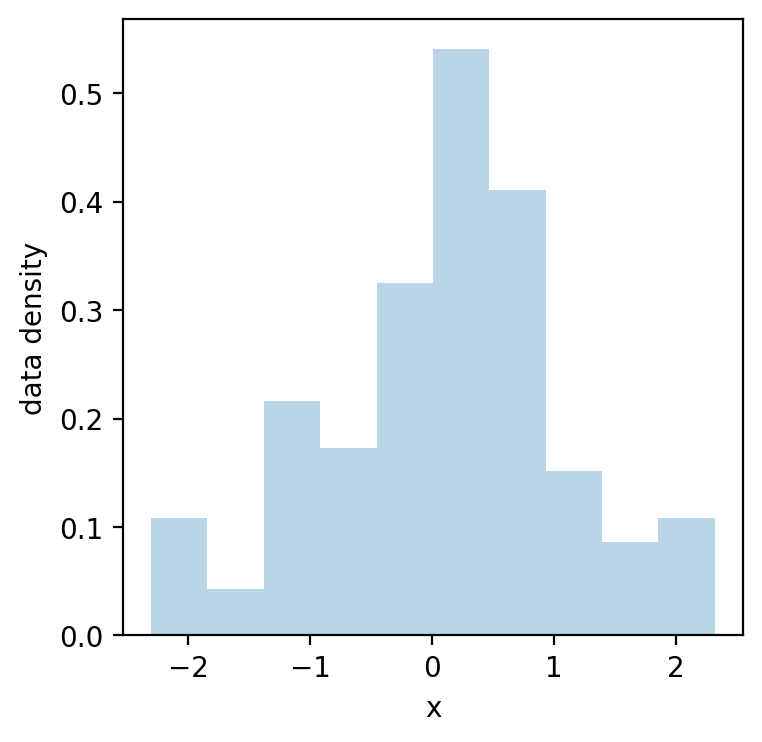

In [33]:
import scipy as sp
import pandas as pd
from scipy.stats import norm
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(124)

data = np.random.randn(100)
print(data)
plt.figure(figsize=(4,4))
plt.hist(data, bins=10, density=True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('data density');

So we have our data, which is generated from a normal distribution centered at 0

But we need our model so lets make some assumptions:

1. Gaussian likelihood distribution $\mathscr{N}(\mu,\sigma=1)$
2. Gaussian prior $\mu \sim \mathscr{N}(0,1)$


We know that the product of two gaussians is a gaussian, so the posterior is:

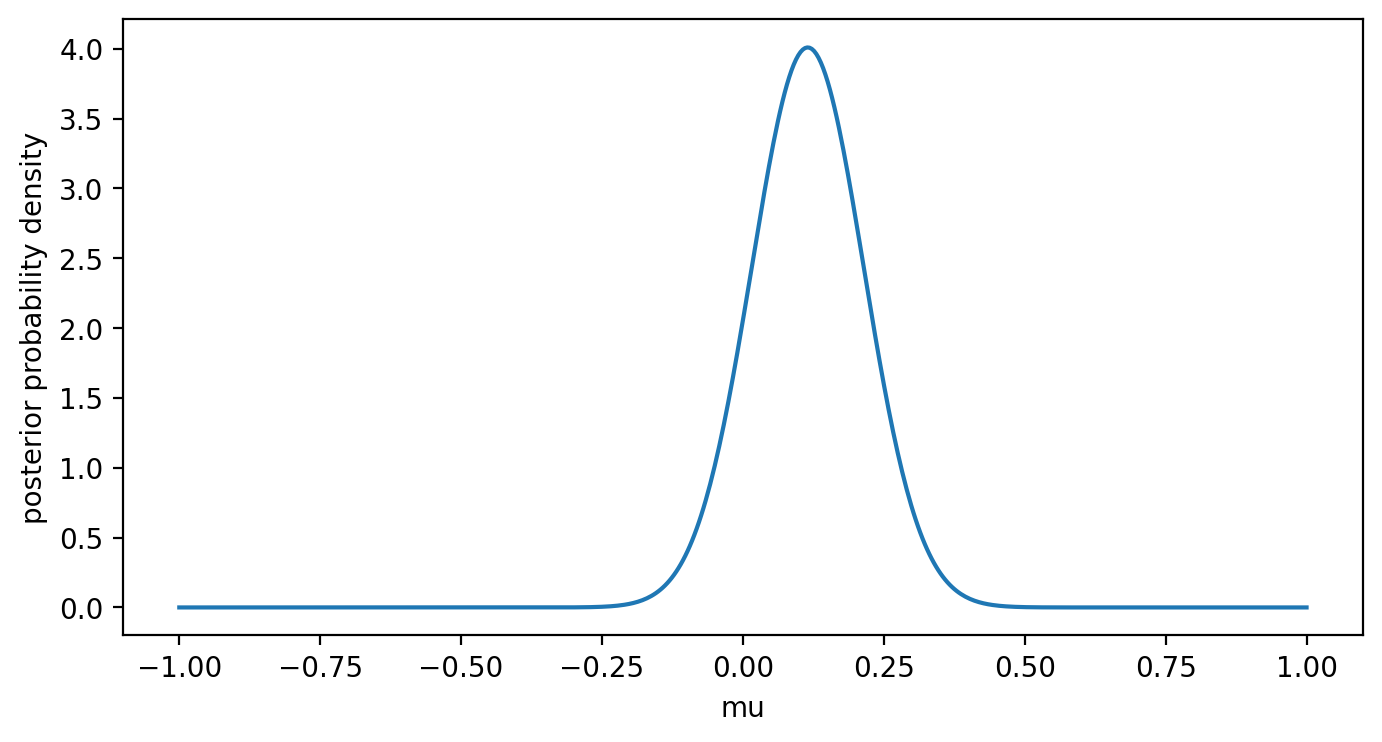

In [ ]:
# Execute this cell
def analytic_posterior(data, xgrid, mean_0, sigma_0):
    n = len(data)
    sigma = 1.


    newmean = (mean_0/sigma_0**2 + np.sum(data) / sigma**2) / (1/sigma_0**2 + n/sigma**2)
    newvariance = (1/sigma_0**2 + n/sigma**2)**(-1)
    return norm.pdf(xgrid, newmean, np.sqrt(newvariance))

plt.figure(figsize=(8,4))
xgrid = np.linspace(-1, 1, 500)
posterior = analytic_posterior(data, xgrid, 0., 1.)
plt.plot(xgrid, posterior)
plt.xlabel('mu')
plt.ylabel('posterior probability density');


This is the analytical solution, we can now try MCMC to see if we recover the same thing:

For MCMC:

1. Start with a trial $\mu_0 = -1$
2. Jump to a new position using the algorithm
3. We see if the jump was productive, by seeing if the value of the likelihood x the prior increases


In [39]:
## Execute this cell
## See https://github.com/twiecki/WhileMyMCMCGentlySamples/blob/master/content/downloads/notebooks/MCMC-sampling-for-dummies.ipynb
def sampler(data, samples=4, mu_init=.5, proposal_width=0.5, 
            plot=False, mu_prior_mu=0, mu_prior_sd=1.):
    mu_current = mu_init
    posterior = [mu_current]
    for i in range(samples):
        # suggest new position
        # changing the width of this distribution changes how big the jump is between trials.
        mu_proposal = norm(mu_current, proposal_width).rvs()

        # Compute likelihood by multiplying probabilities of each data point
        likelihood_current = norm(mu_current, 1).pdf(data).prod()
        likelihood_proposal = norm(mu_proposal, 1).pdf(data).prod()
        
        # Compute prior probability of current and proposed mu        
        prior_current = norm(mu_prior_mu, mu_prior_sd).pdf(mu_current)
        prior_proposal = norm(mu_prior_mu, mu_prior_sd).pdf(mu_proposal)
        
        p_current = likelihood_current * prior_current
        p_proposal = likelihood_proposal * prior_proposal
        
        # Accept proposal?
        p_accept = p_proposal / p_current
        
        # Usually would include prior probability, which we neglect here for simplicity
        # Accept if p_accept > 1 (since random limited to [0,1]) and if p_accept > rand as well
        accept = np.random.rand() < p_accept
        
        if plot:
            plot_proposal(mu_current, mu_proposal, mu_prior_mu, 
                          mu_prior_sd, data, accept, posterior, i)
        
        if accept:
            # Update position
            mu_current = mu_proposal
        
        posterior.append(mu_current)
        
    return posterior

## Function to display
def plot_proposal(mu_current, mu_proposal, mu_prior_mu, 
                  mu_prior_sd, data, accepted, trace, i):
    from copy import copy
    trace = copy(trace)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, figsize=(16, 4))
    fig.suptitle('Iteration %i' % (i + 1))
    xgrid = np.linspace(-3, 3, 5000)
    color = 'g' if accepted else 'r'
        
    # Plot prior
    prior_current = norm(mu_prior_mu, mu_prior_sd).pdf(mu_current)
    prior_proposal = norm(mu_prior_mu, mu_prior_sd).pdf(mu_proposal)
    prior = norm.pdf(xgrid,mu_prior_mu, mu_prior_sd)
    ax1.plot(xgrid, prior)
    ax1.plot([mu_current] * 2, [0, prior_current], marker='o', color='b')
    ax1.plot([mu_proposal] * 2, [0, prior_proposal], marker='o', color=color)
    ax1.annotate("", xy=(mu_proposal, 0.2), xytext=(mu_current, 0.2),
                 arrowprops=dict(arrowstyle="->", lw=2.))
    ax1.set(ylabel='Probability Density', 
            title='current: prior(mu=%.2f) = %.2f\nproposal: prior(mu=%.2f) = %.2f' % (mu_current, 
                                                                                       prior_current, 
                                                                                       mu_proposal, 
                                                                                       prior_proposal))
    
    # Likelihood
    likelihood_current = norm(mu_current, 1).pdf(data).prod()
    likelihood_proposal = norm(mu_proposal, 1).pdf(data).prod()
    y = norm.pdf(xgrid,loc=mu_proposal, scale=1)
    
    ax2.hist(data,alpha=0.5,density='True')
    ax2.plot(xgrid, y, color=color)
    ax2.axvline(mu_current, color='b', linestyle='--', label='mu_current')
    ax2.axvline(mu_proposal, color=color, linestyle='--', label='mu_proposal')
    
    ax2.annotate("", xy=(mu_proposal, 0.2), xytext=(mu_current, 0.2),
                 arrowprops=dict(arrowstyle="->", lw=2.))
    ax2.set(title='likelihood(mu=%.2f) = %.2f\nlikelihood(mu=%.2f) = %.2f' % (mu_current, 
                                                                              1e14*likelihood_current, 
                                                                              mu_proposal, 
                                                                              1e14*likelihood_proposal))
    
    # Posterior
    posterior_analytical = calc_posterior_analytical(data, xgrid, 
                                                     mu_prior_mu, 
                                                     mu_prior_sd)
    ax3.plot(xgrid, posterior_analytical)
    posterior_current = calc_posterior_analytical(data, mu_current, 
                                                  mu_prior_mu, mu_prior_sd)
    posterior_proposal = calc_posterior_analytical(data, mu_proposal, 
                                                   mu_prior_mu, mu_prior_sd)
    ax3.plot([mu_current] * 2, [0, posterior_current], marker='o', color='b')
    ax3.plot([mu_proposal] * 2, [0, posterior_proposal], marker='o', color=color)
    ax3.annotate("", xy=(mu_proposal, 0.2), xytext=(mu_current, 0.2),
                 arrowprops=dict(arrowstyle="->", lw=2.))
    
    ax3.set(title='posterior(mu=%.2f) = %.5f\nposterior(mu=%.2f) = %.5f' % (mu_current, 
                                                                            posterior_current, 
                                                                            mu_proposal, 
                                                                            posterior_proposal)) 
    if accepted:
        trace.append(mu_proposal)
    else:
        trace.append(mu_current)
    ax4.plot(trace)
    ax4.set(xlabel='iteration', ylabel='mu', title='trace')
    plt.tight_layout()

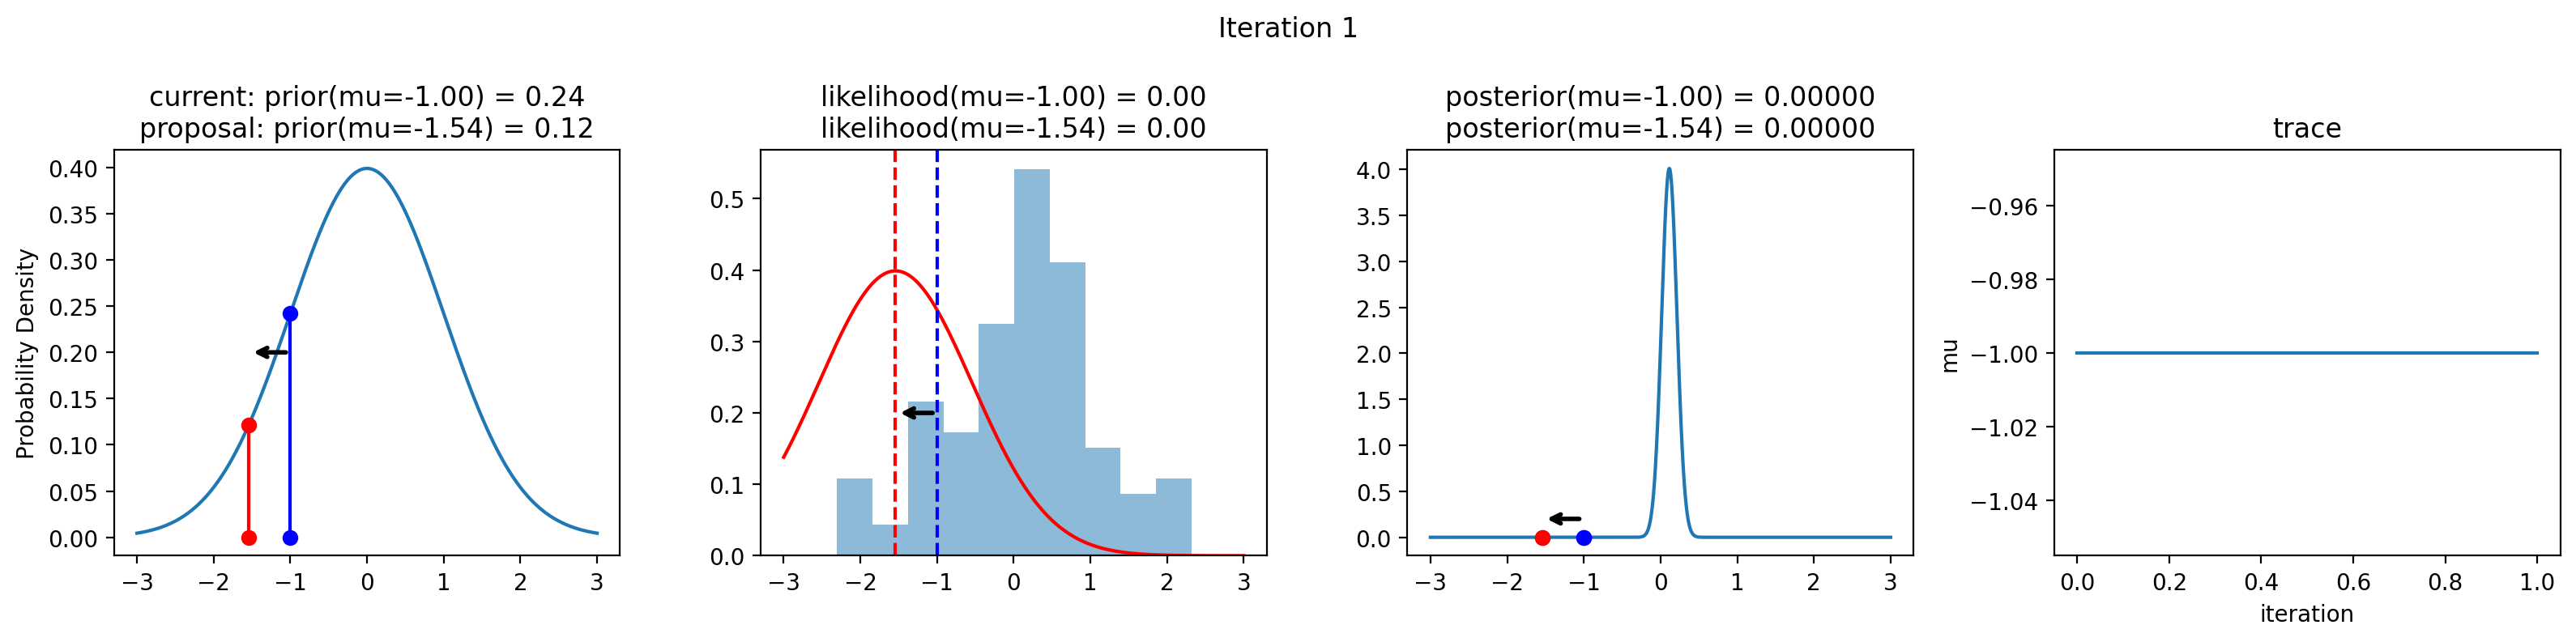

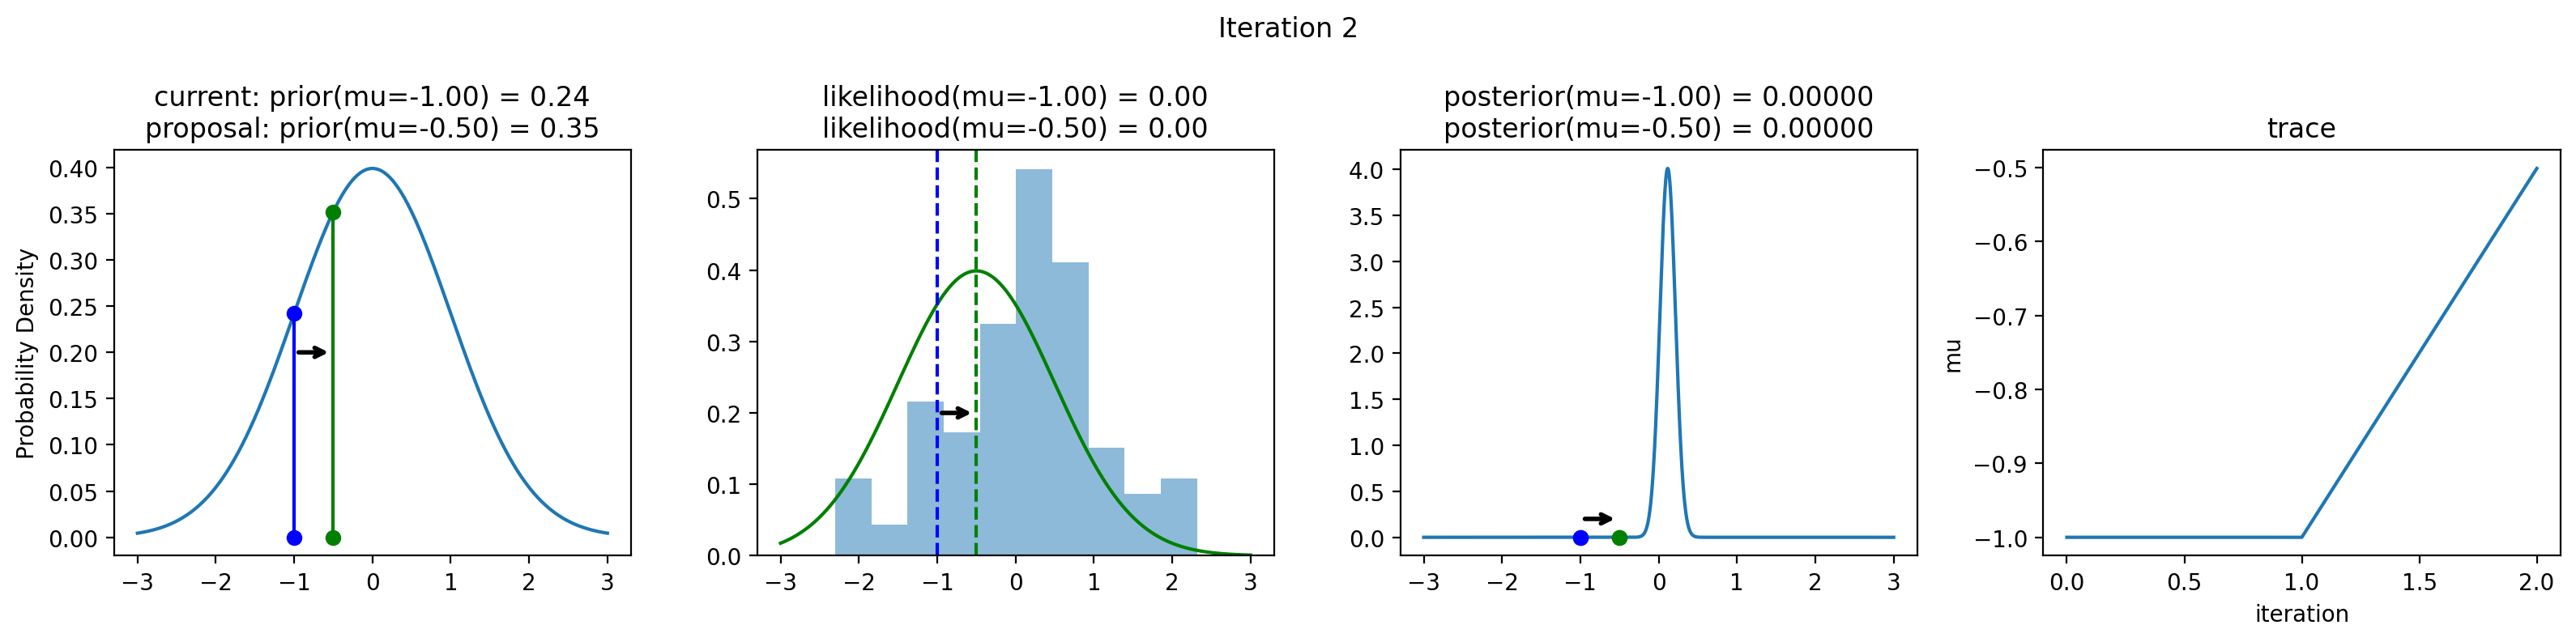

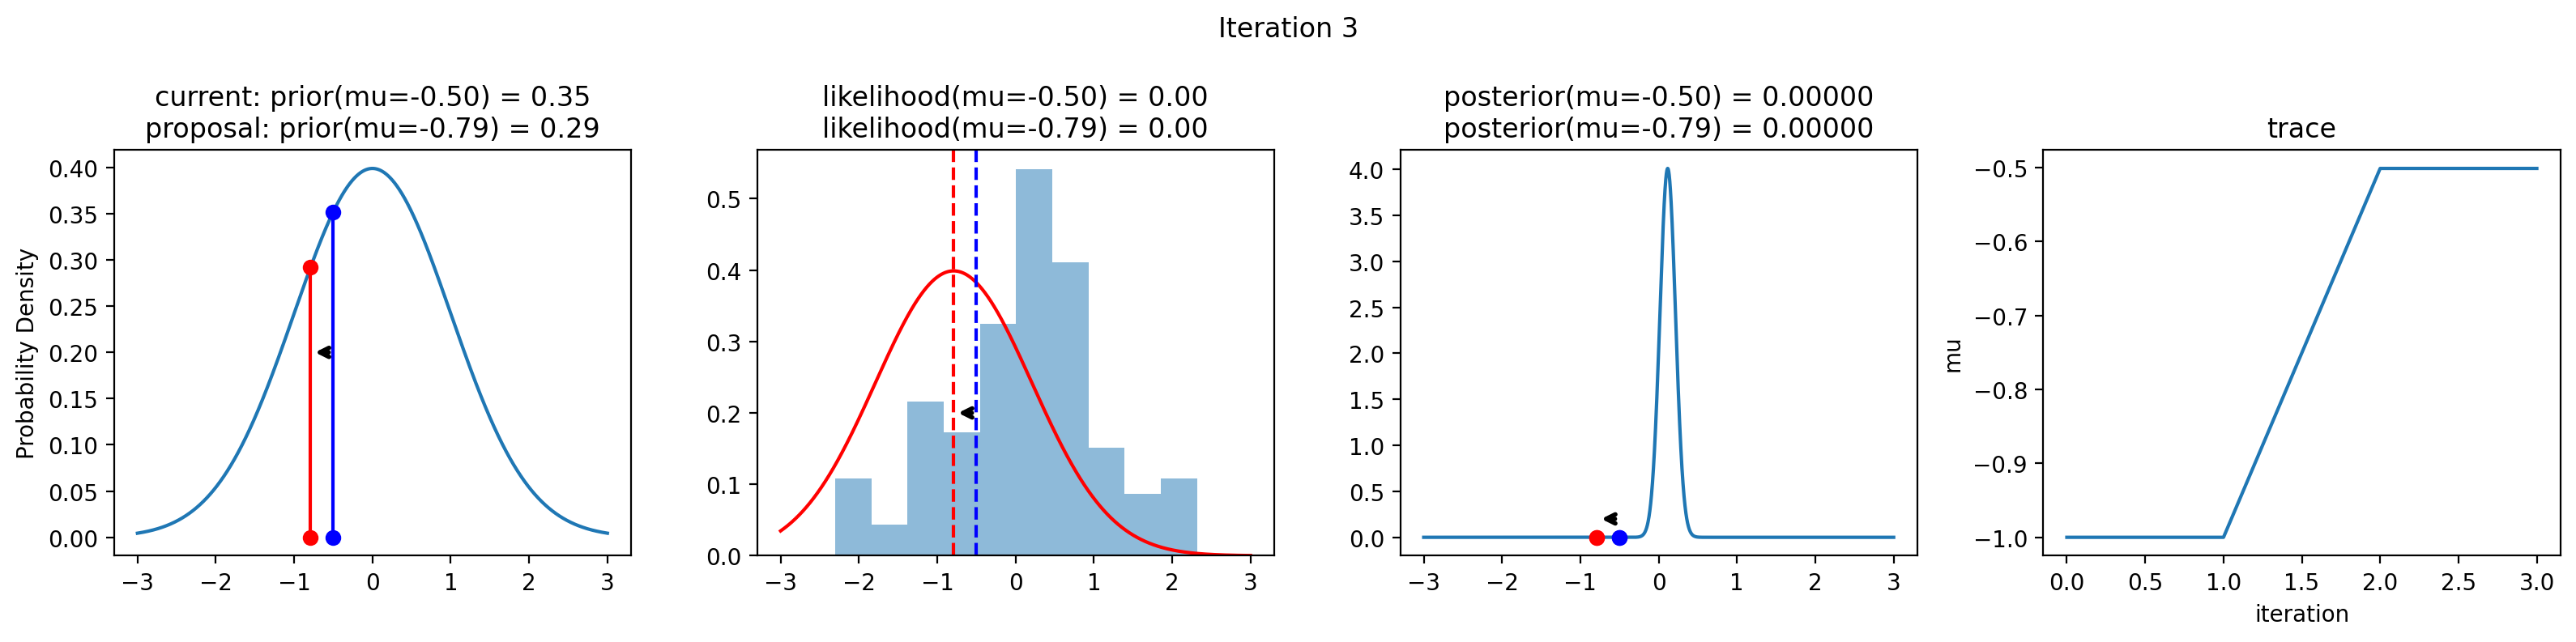

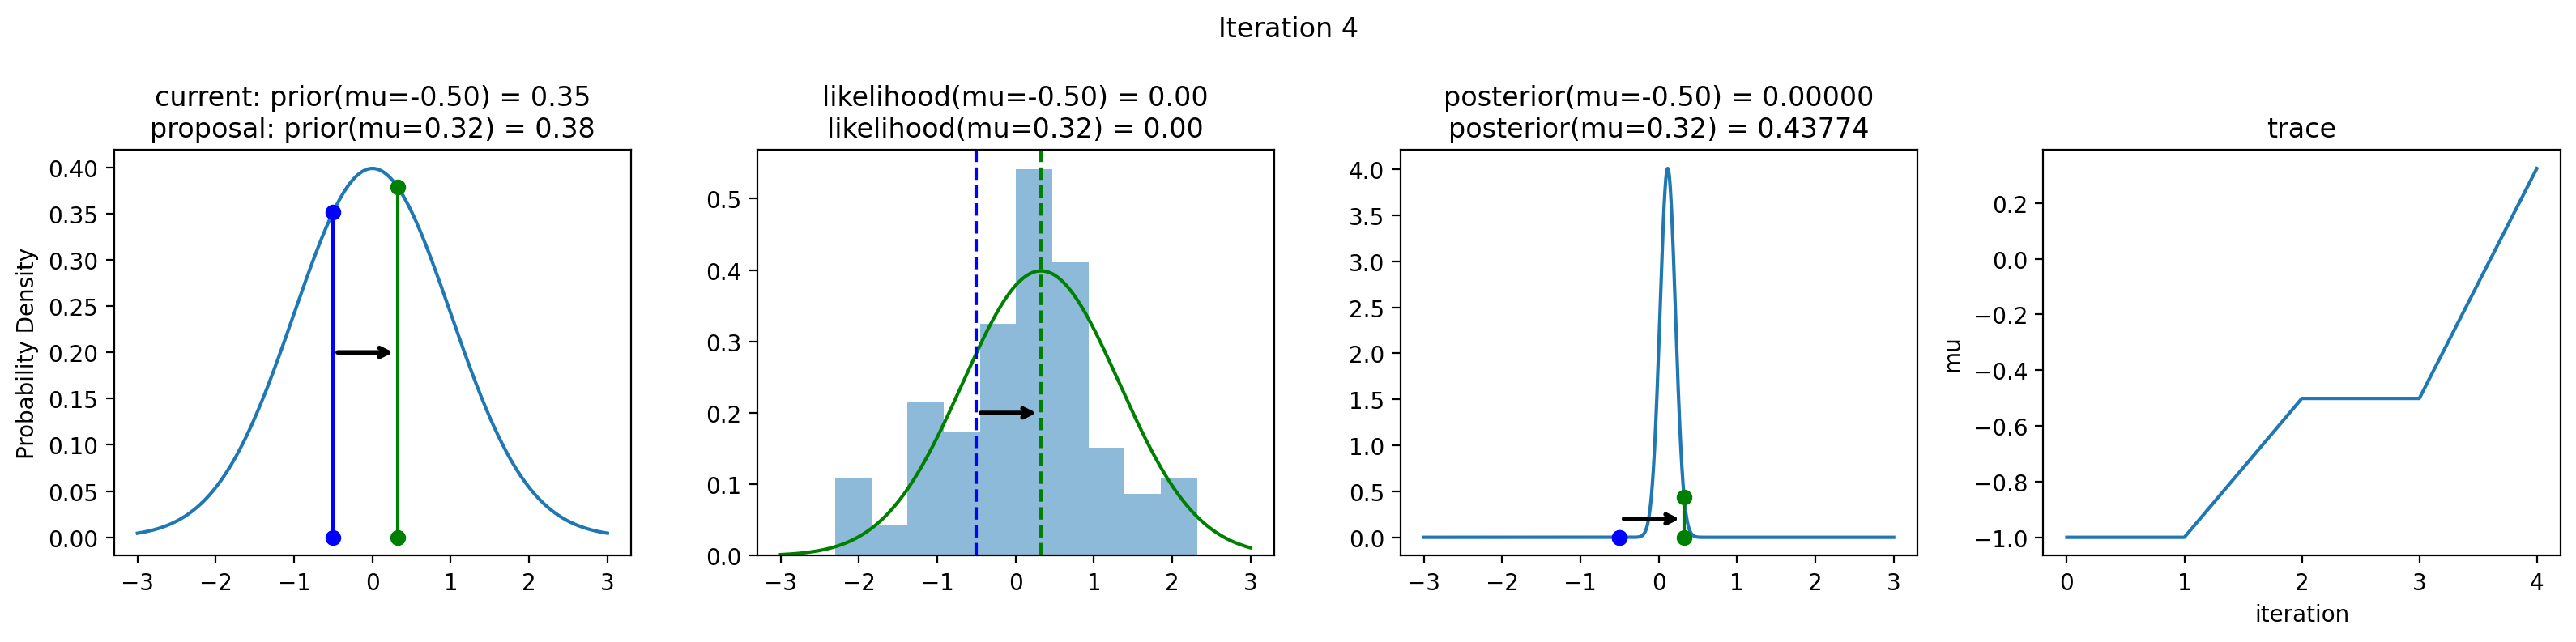

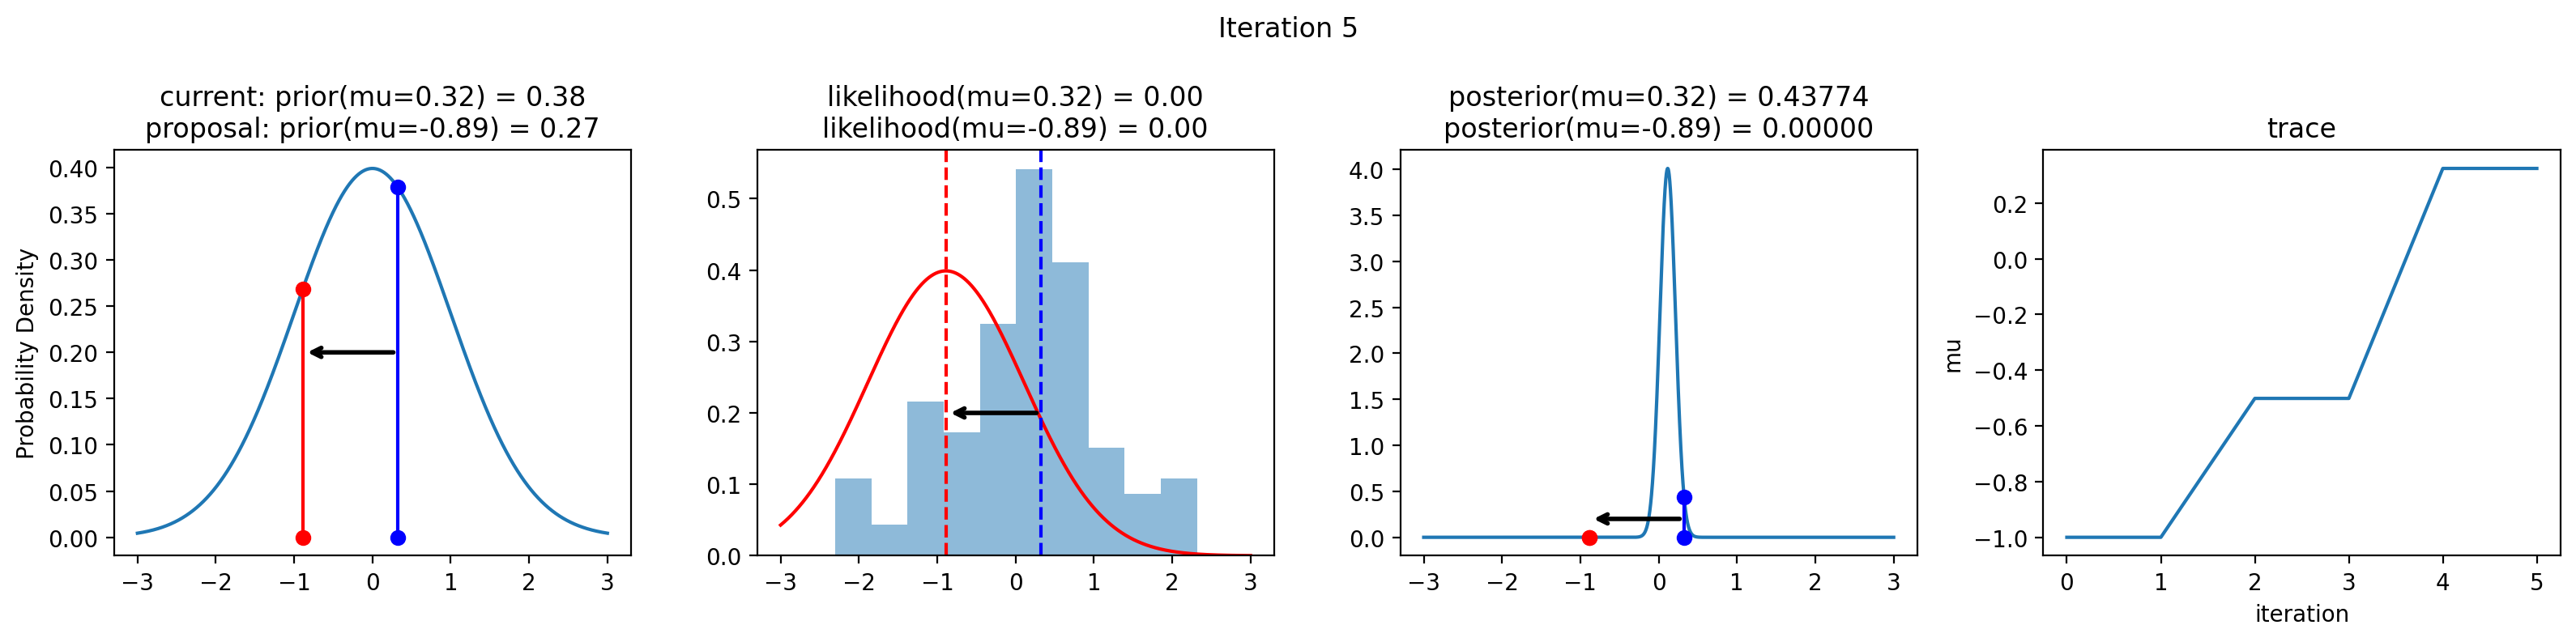

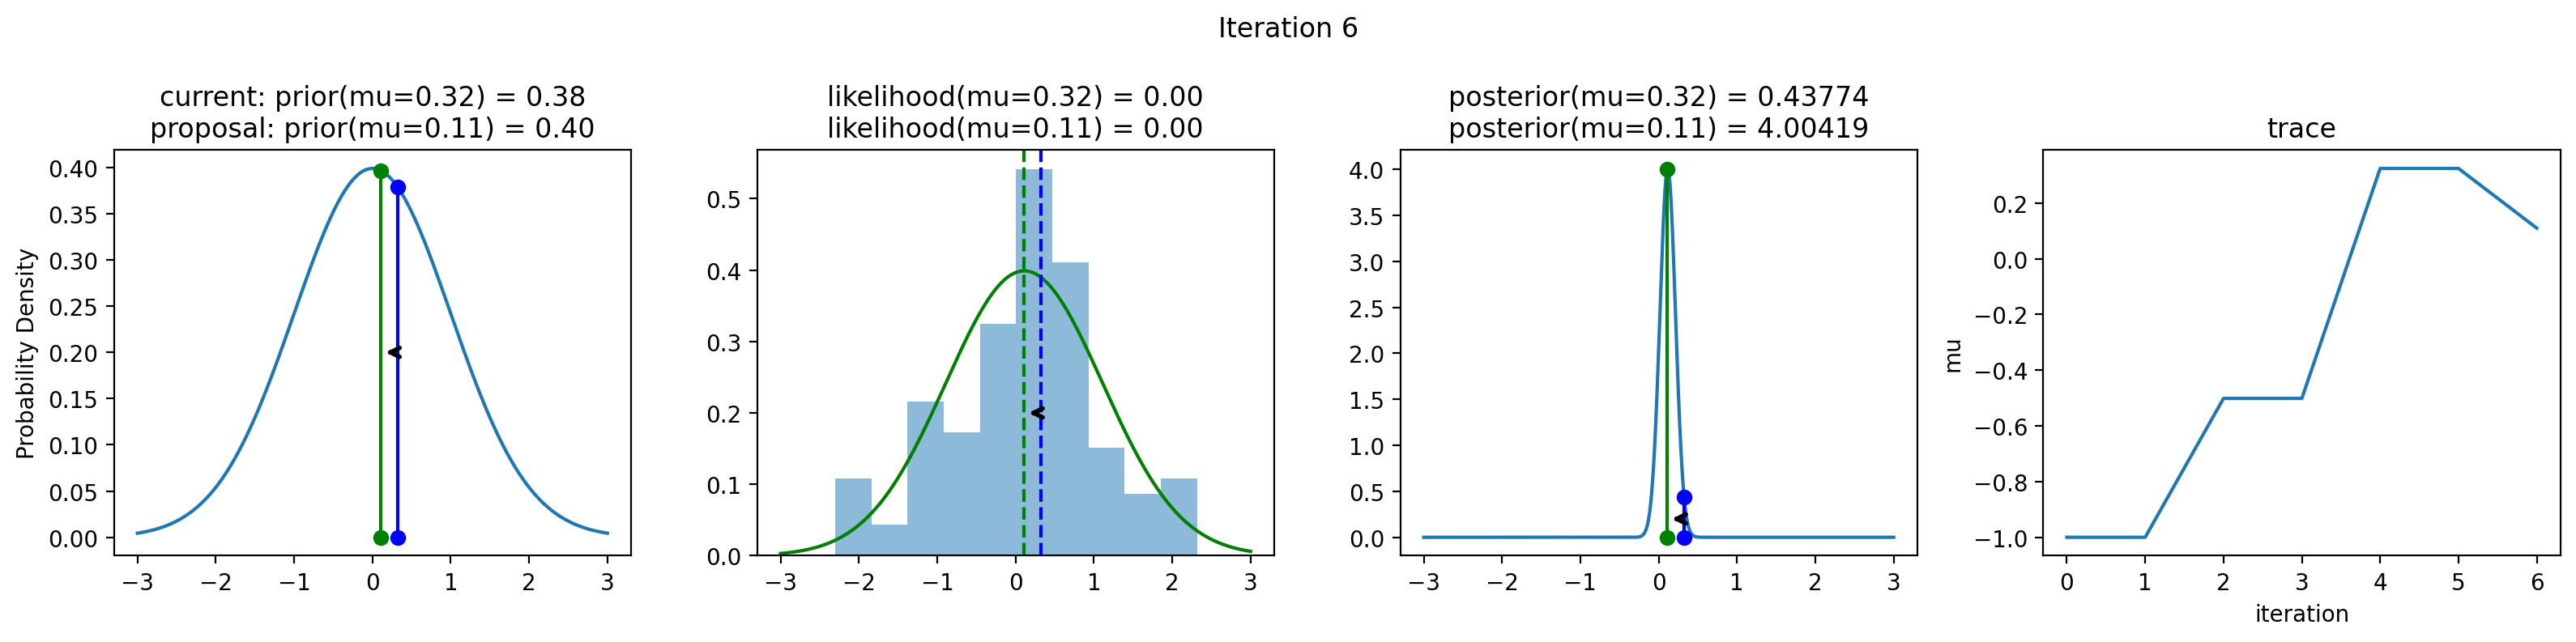

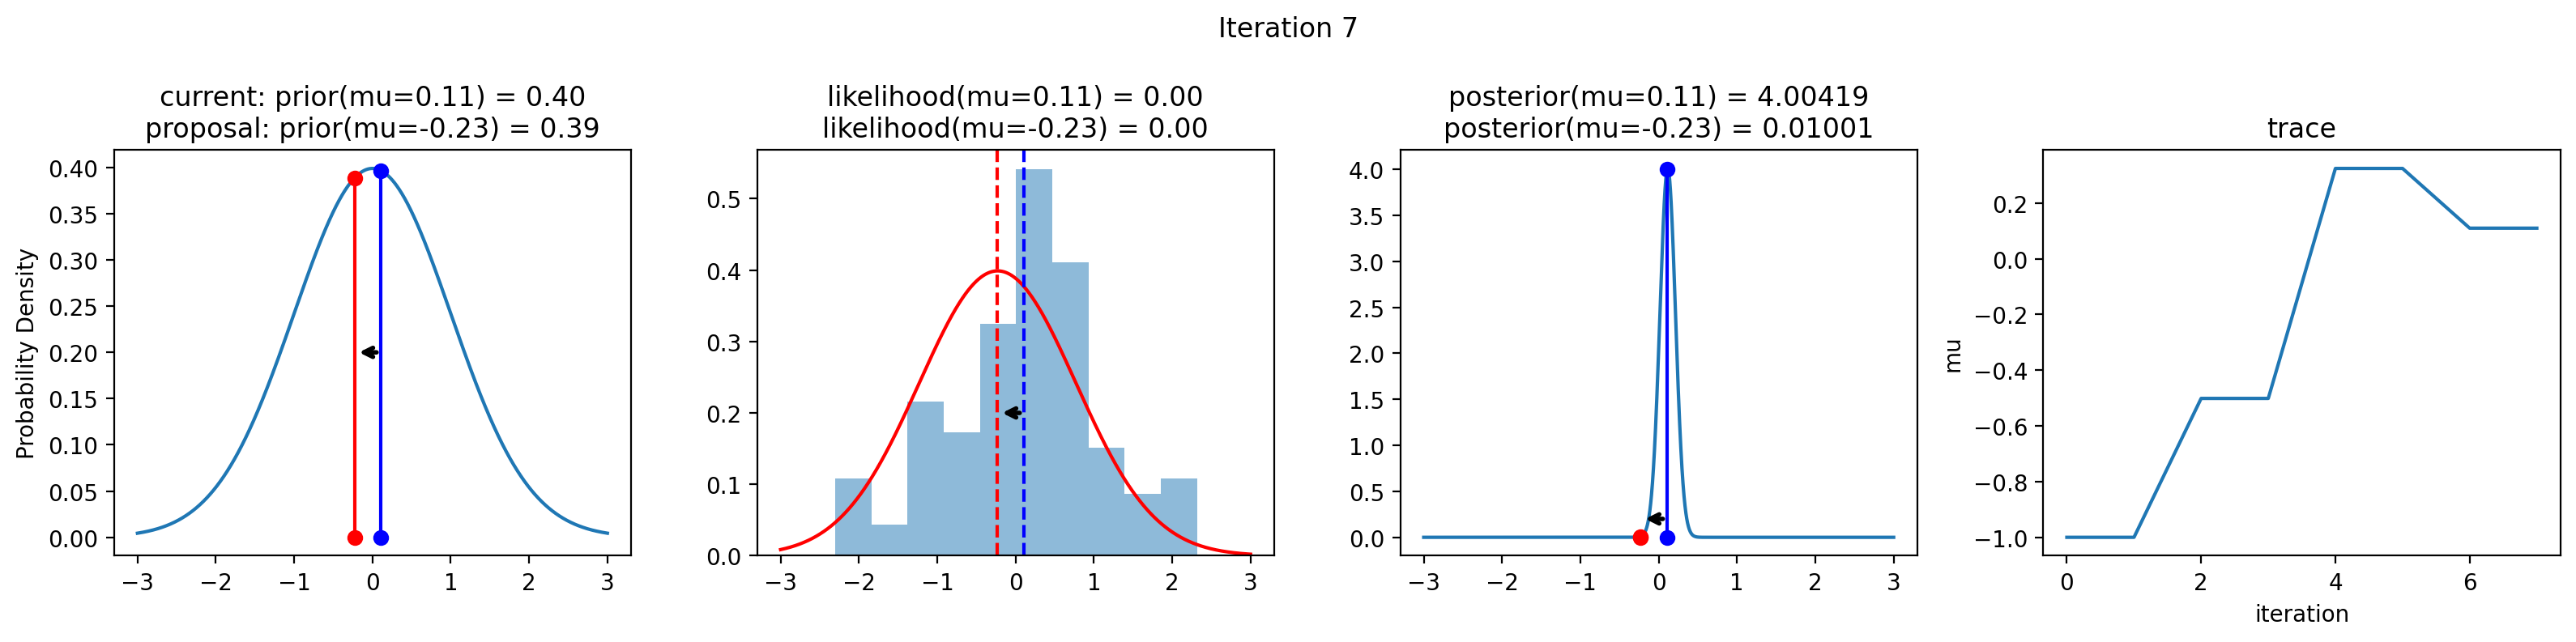

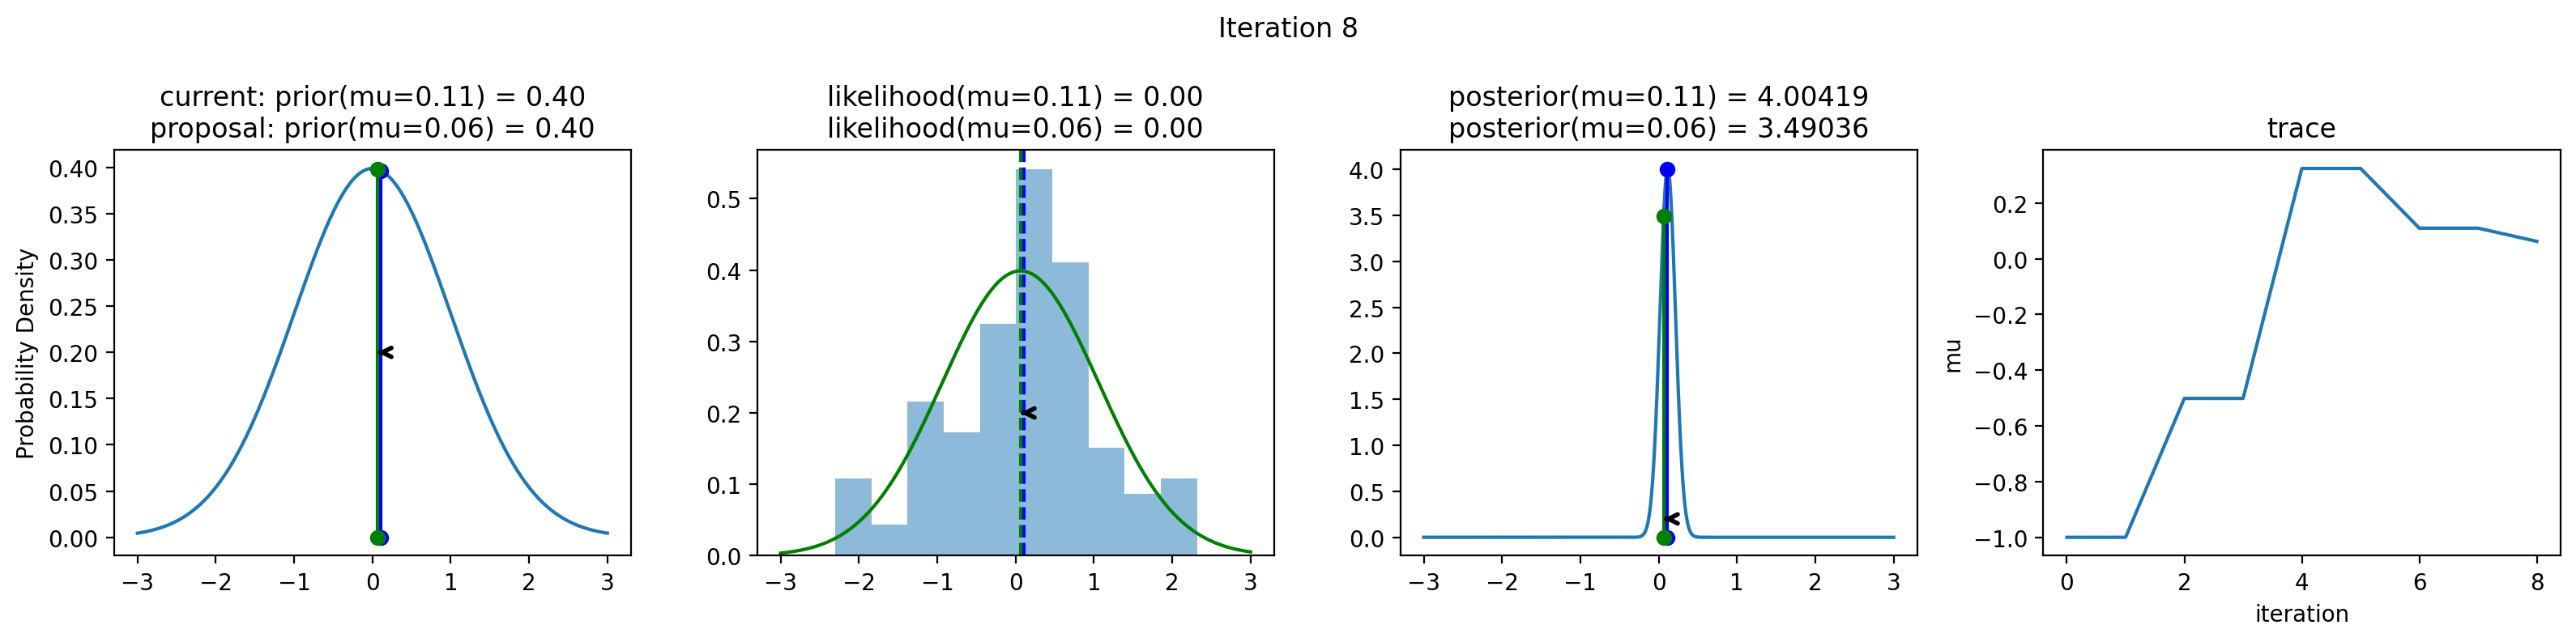

In [22]:
np.random.seed(123)
samples = sampler(data, samples=8, mu_init=-1., plot=True);





Lets plot these results as a histogram to get our estimated posterior probability distribution, removing the burn in 

> The burn in is the initial part of the chain, when the distribution still strongly reflects the starting point rather than the stationary distribution we want

We can see the burn in below:

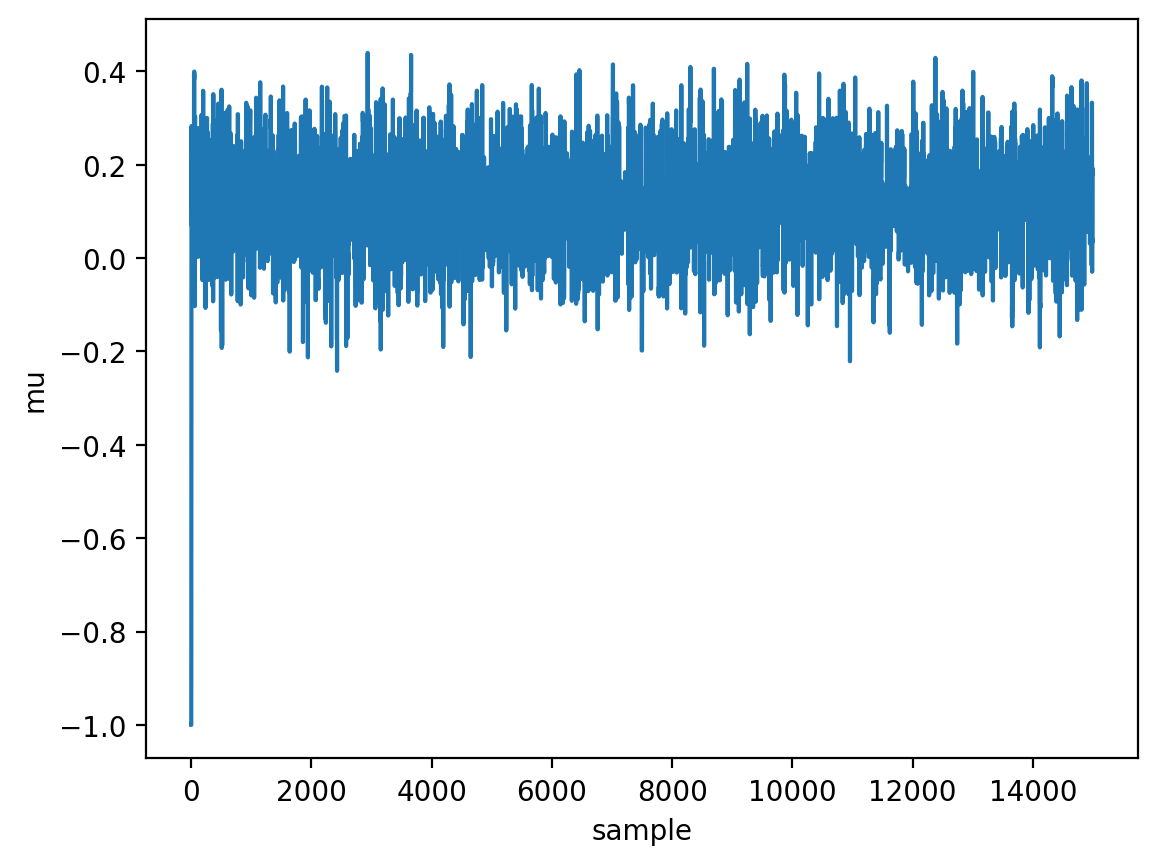

In [23]:
posterior = sampler(data, samples=15000, mu_init=-1.)
fig, ax = plt.subplots()
ax.plot(posterior)
ax.set(xlabel='sample', ylabel='mu');



C:\Users\krist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


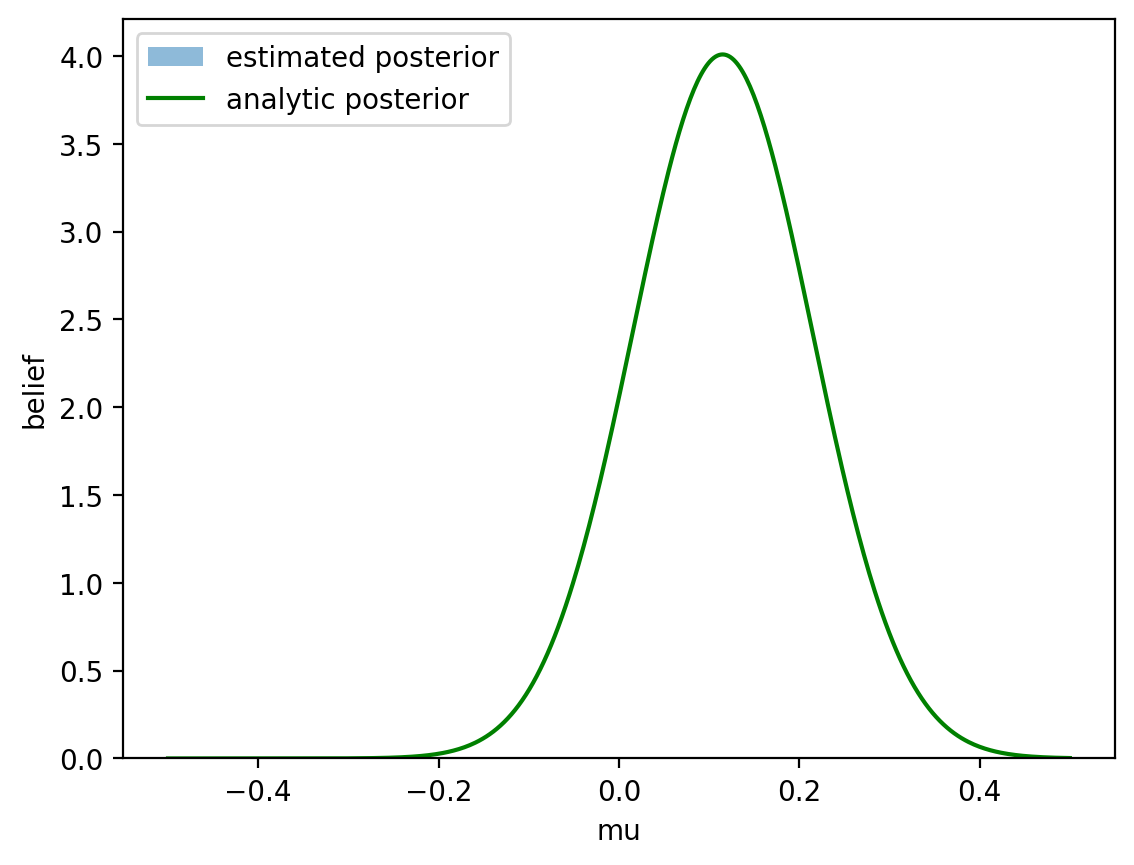

In [40]:
ax = plt.subplot()

burn = 500
ax.hist(posterior[burn:], bins=30, alpha=0.5, 
        density='True', label='estimated posterior')

xplot = np.linspace(-.5, .5, 500)
post = analytic_posterior(data, xplot, 0, 1)
ax.plot(xplot, post, 'g', label='analytic posterior')
ax.set(xlabel='mu', ylabel='belief');

ax.legend(fontsize=10);

Now we have to compute the expected value of $\mu$, the credible regions and the MAP values:

In [25]:
# expected value
ex_mu = np.mean(posterior[burn:])

# 68% equal-tailed credible region
lower, upper = np.percentile(posterior[burn:],q=16), np.percentile(posterior[burn:],q=84)   

# MAP value
# many samplers output the likelihood x prior, 
# so it's usually than this
hist, bins = np.histogram(posterior[burn:], bins=30)
bin_mid = 0.5 * (bins[1:] + bins[:-1])
idx = np.argsort(hist)[-1]
map_theta = bin_mid[idx]

print('Expected value of mu = ' + str(ex_mu))
print('68% credible region = ' + str(lower) + ' to ' + str(upper))
print('MAP value = ' + str(map_theta))

Expected value of mu = 0.11939142531544528
68% credible region = 0.019337821241809078 to 0.2189742678637321
MAP value = 0.13328429310839593
